# Block 2 — Distributions for Business Simulation

**ODSC Tutorial: Spec-Driven Simulation Modeling**

In this block we move from the conceptual landscape of Block 1 to the statistical foundations our simulation will rest on. We have six months of point-of-sale data from the coffee shop. Before we can build a credible discrete event simulation, we need answers to two questions:

1. *How* do customers arrive?
2. *How long* does it take to serve them?

For each, we will pick a candidate distribution from domain knowledge, fit parameters from data with `scipy.stats`, and assess fit visually and with a Kolmogorov–Smirnov test. By the end of this block you will have the parameters that drive the simulation in Blocks 4–6.

## Setup

Standard imports. The `DATA_PATH` cell points at the workshop dataset; if you've placed it elsewhere, adjust the path.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Workshop default. Adjust if you put the file somewhere else.
DATA_PATH = "../data/coffee_shop_pos.csv"

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Load the data and orient yourself

Six months of weekday transactions, one row per customer. The fields that matter for fitting are `arrival_timestamp` and `service_duration_min`. The `order_type` field will let us see how service-time distributions vary across drink types.

In [3]:
df = pd.read_csv(DATA_PATH, parse_dates=["arrival_timestamp"])
print(f"Rows: {len(df):,}")
print(f"Date range: {df['arrival_timestamp'].min().date()} → {df['arrival_timestamp'].max().date()}")
print(f"Distinct days: {df['arrival_timestamp'].dt.date.nunique()}")
df.head()

Rows: 21,822
Date range: 2025-10-06 → 2026-04-03
Distinct days: 130


,transaction_id,arrival_timestamp,order_type,service_duration_min
0,20251006-0000,2025-10-06 07:04:48,espresso,3.8598
1,20251006-0001,2025-10-06 07:09:28,blended,5.4722
2,20251006-0002,2025-10-06 07:14:15,blended,5.0026
3,20251006-0003,2025-10-06 07:14:48,drip,2.3076
4,20251006-0004,2025-10-06 07:14:58,drip,2.6662


In [4]:
# A quick look at the order mix and the typical service times
print("Order-type mix:")
print(df['order_type'].value_counts(normalize=True).round(3).to_string())

print("\nService duration summary (minutes):")
print(df['service_duration_min'].describe().round(2).to_string())

Order-type mix:
order_type
espresso    0.504
drip        0.294
blended     0.202

Service duration summary (minutes):
count    21822.00
mean         3.34
std          1.48
min          0.68
25%          2.22
50%          3.08
75%          4.17
max         15.57


## 2. Arrival rate by hour

Before fitting any distribution, look at the data. If we plot mean arrivals per hour we should see a clear morning rush and an intraday rate pattern. That visual is what justifies modeling arrivals as a *piecewise* Poisson process — different rates in different time windows — rather than a single global rate.

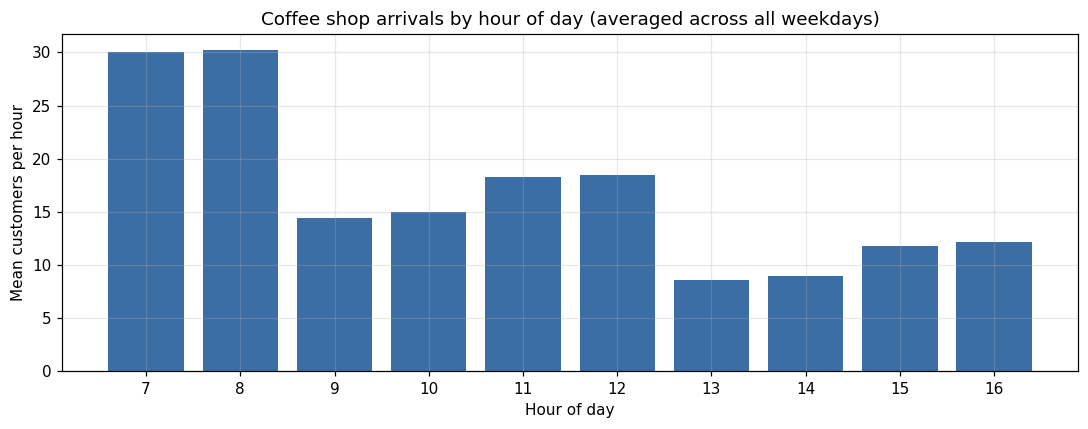

hour
7     30.05
8     30.21
9     14.46
10    14.97
11    18.28
12    18.43
13     8.54
14     8.92
15    11.82
16    12.19


In [5]:
df['hour'] = df['arrival_timestamp'].dt.hour
df['date'] = df['arrival_timestamp'].dt.date
n_days = df['date'].nunique()

hourly = df.groupby('hour').size() / n_days

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hourly.index, hourly.values, color="#3B6EA5")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean customers per hour")
ax.set_title("Coffee shop arrivals by hour of day (averaged across all weekdays)")
ax.set_xticks(hourly.index)
plt.tight_layout()
plt.show()

print(hourly.round(2).to_string())

The morning rush jumps out: roughly 30 customers per hour from 7 to 9 AM. The shop quiets down to about 14/hr from 9 to 11, picks up around lunch (~18/hr), drops to a lull (~9/hr) from 1 to 3, and recovers slightly in the late afternoon (~12/hr).

These five rate windows are exactly what our SimPy simulation will use in Block 4. The point of fitting is to recover those rates *from data* so that participants can apply the same workflow to their own systems where the rates aren't known in advance.

## 3. Fit the morning-rush arrivals

If arrivals follow a Poisson process at constant rate λ within a window, then the *gaps between consecutive arrivals* (inter-arrival times) are exponential with mean 1/λ. We can therefore fit an exponential distribution to the inter-arrival times within the morning-rush window and recover the arrival rate from the fitted scale parameter.

A few practical notes:

- **Compute inter-arrivals within each day.** Don't subtract the first morning arrival from the previous day's last arrival; that gap is meaningless.
- **`floc=0` in `expon.fit`.** SciPy's `expon` is a two-parameter family with a location shift. We constrain location to zero because inter-arrival times are positive and start at zero by definition.

In [6]:
# Restrict to the morning-rush window: 7:00 to 9:00 AM
rush = df[(df['arrival_timestamp'].dt.hour >= 7) & (df['arrival_timestamp'].dt.hour < 9)].copy()
rush = rush.sort_values('arrival_timestamp')
rush['inter_min'] = rush.groupby(rush['arrival_timestamp'].dt.date)['arrival_timestamp'].diff().dt.total_seconds() / 60.0
inter = rush['inter_min'].dropna().values

print(f"Inter-arrival samples: {len(inter):,}")
print(f"Mean gap: {inter.mean():.3f} min  →  empirical rate: {60.0/inter.mean():.2f} per hour")

Inter-arrival samples: 7,704
Mean gap: 1.956 min  →  empirical rate: 30.67 per hour


In [7]:
# Fit an exponential distribution. floc=0 holds the location at zero.
loc, scale = stats.expon.fit(inter, floc=0)
fitted_rate_per_hour = 60.0 / scale
print(f"Fitted scale (mean gap): {scale:.3f} min")
print(f"Fitted rate:             {fitted_rate_per_hour:.2f} customers per hour")

Fitted scale (mean gap): 1.956 min
Fitted rate:             30.67 customers per hour


**Visual fit assessment.** A histogram of the inter-arrivals with the fitted PDF overlaid is the first check. A Q-Q plot is the second — a clean diagonal means the fit is good across the full range, including the tail.

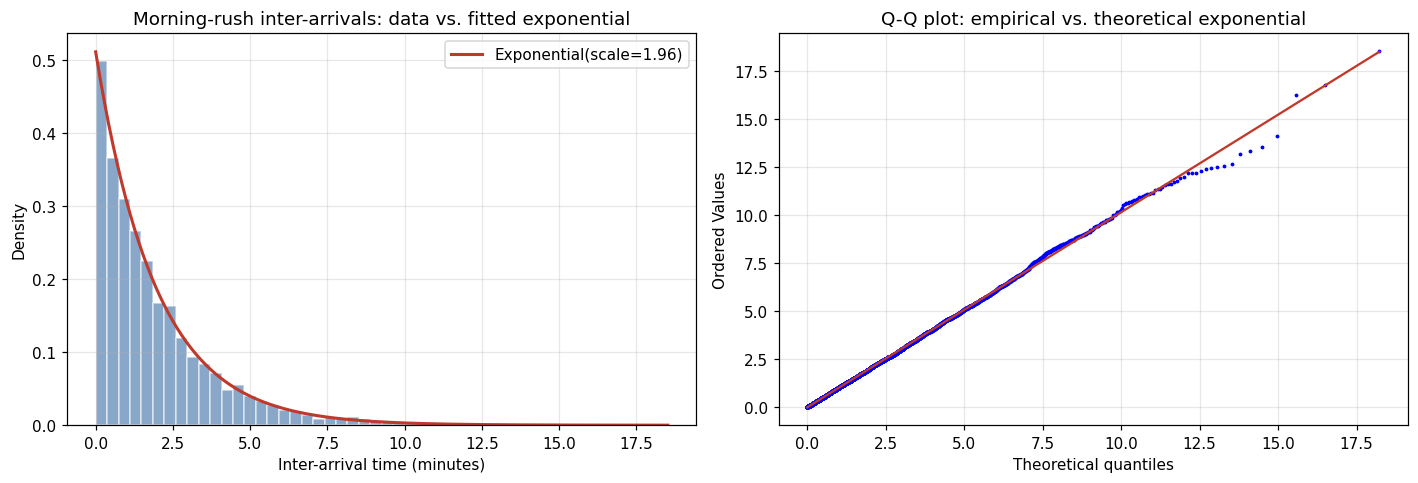

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Histogram + fitted PDF
ax = axes[0]
ax.hist(inter, bins=50, density=True, alpha=0.6, color="#3B6EA5", edgecolor="white")
xs = np.linspace(0, inter.max(), 400)
ax.plot(xs, stats.expon.pdf(xs, loc=loc, scale=scale), color="#C0392B", linewidth=2, label=f"Exponential(scale={scale:.2f})")
ax.set_xlabel("Inter-arrival time (minutes)")
ax.set_ylabel("Density")
ax.set_title("Morning-rush inter-arrivals: data vs. fitted exponential")
ax.legend()

# Q-Q plot
ax = axes[1]
stats.probplot(inter, dist="expon", sparams=(loc, scale), plot=ax)
ax.get_lines()[0].set_marker(".")
ax.get_lines()[0].set_markersize(3)
ax.get_lines()[1].set_color("#C0392B")
ax.set_title("Q-Q plot: empirical vs. theoretical exponential")

plt.tight_layout()
plt.show()

The Kolmogorov–Smirnov test gives a numeric sanity check. Treat the p-value as a guardrail, not a hard pass-fail: with this much data, even a small deviation from the model can produce a tiny p-value, and a very large p-value is no guarantee the distribution is the right choice for downstream use.

In [9]:
ks_stat, ks_p = stats.kstest(inter, 'expon', args=(loc, scale))
print(f"KS statistic: {ks_stat:.4f}")
print(f"KS p-value:   {ks_p:.4f}")

KS statistic: 0.0137
KS p-value:   0.1117


## 4. Fit the service-time distributions

Service times are positive and right-skewed: most drinks take roughly the same time but a few complex orders or equipment hiccups create a long tail. The lognormal distribution is the standard choice for this shape.

We will fit a separate lognormal to each order type — drip, espresso, blended — because the means and variability differ. Drip is fast and consistent. Espresso is slower with more variability. Blended drinks are slowest. Mixing them into a single fit would smear out structure that matters for the simulation.

**SciPy's lognormal parameterization is fiddly.** `stats.lognorm.fit` returns three values: `(s, loc, scale)`. The relationship to the standard log-space parameters $(\mu, \sigma)$ is:

- `s` is $\sigma$ (standard deviation of the log of the variable)
- `loc` is a location shift; for a true lognormal we hold this at zero with `floc=0`
- `scale` is $e^\mu$, so $\mu = \log(\text{scale})$

In [10]:
order_types = ["drip", "espresso", "blended"]
colors = {"drip": "#2196F3", "espresso": "#4CAF50", "blended": "#FF9800"}

fits = {}
for ot in order_types:
    s = df.loc[df['order_type'] == ot, 'service_duration_min'].values
    sigma_hat, loc_, scale_ = stats.lognorm.fit(s, floc=0)
    mu_hat = float(np.log(scale_))
    ks_stat, ks_p = stats.kstest(s, 'lognorm', args=(sigma_hat, loc_, scale_))
    real_mean = float(np.exp(mu_hat + 0.5 * sigma_hat**2))
    fits[ot] = {
        "n": len(s),
        "mu": mu_hat,
        "sigma": sigma_hat,
        "real_mean_min": real_mean,
        "ks_stat": ks_stat,
        "ks_p": ks_p,
        "samples": s,
    }

summary = pd.DataFrame({
    "n": [fits[o]["n"] for o in order_types],
    "fitted_mu": [round(fits[o]["mu"], 3) for o in order_types],
    "fitted_sigma": [round(fits[o]["sigma"], 3) for o in order_types],
    "real_mean_min": [round(fits[o]["real_mean_min"], 2) for o in order_types],
    "ks_stat": [round(fits[o]["ks_stat"], 4) for o in order_types],
    "ks_p": [round(fits[o]["ks_p"], 3) for o in order_types],
}, index=order_types)
summary

,n,fitted_mu,fitted_sigma,real_mean_min,ks_stat,ks_p
drip,6420,0.698,0.301,2.10,0.0065,0.944
espresso,10988,1.201,0.351,3.53,0.0080,0.477
blended,4414,1.494,0.303,4.66,0.0088,0.884


The means line up with intuition. Drip averages around two minutes, espresso a little over three and a half, blended drinks closer to five. KS p-values comfortably above 0.05 for all three.

Now plot each fit on top of its data so you can *see* the agreement, and overlay the three fitted PDFs on a common axis to visualize how the order types differ.

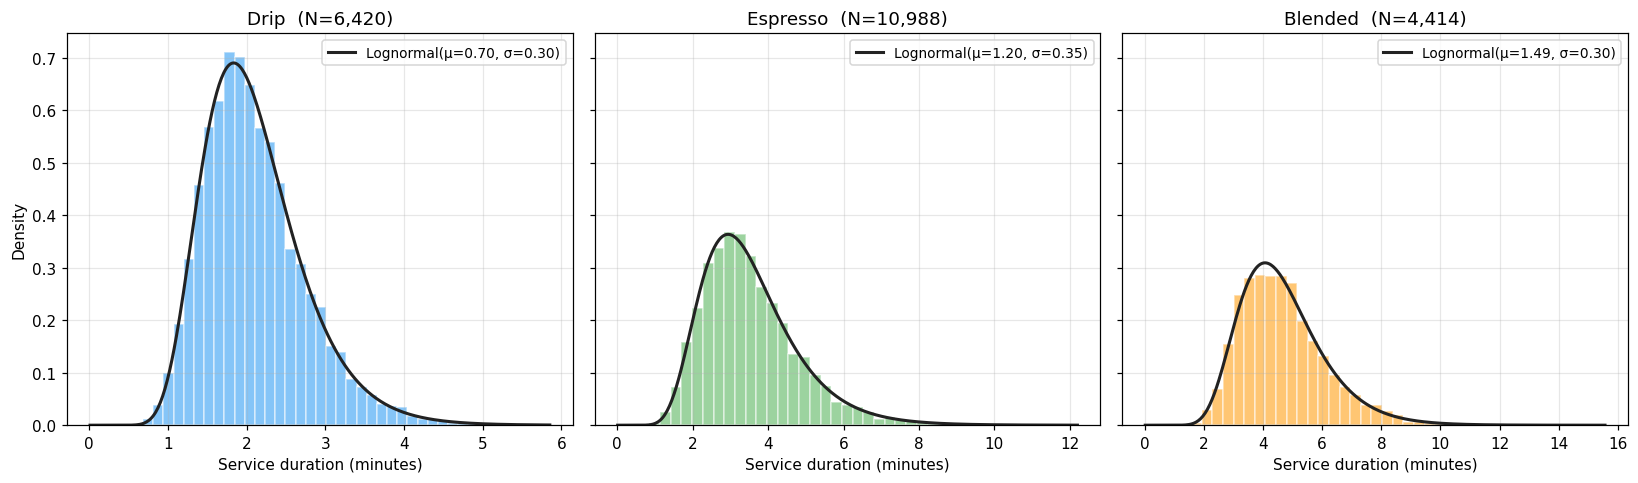

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, ot in zip(axes, order_types):
    s = fits[ot]["samples"]
    ax.hist(s, bins=40, density=True, alpha=0.55, color=colors[ot], edgecolor="white")
    xs = np.linspace(0.01, s.max(), 400)
    pdf = stats.lognorm.pdf(xs, fits[ot]["sigma"], loc=0, scale=np.exp(fits[ot]["mu"]))
    ax.plot(xs, pdf, color="#222", linewidth=2, label=f"Lognormal(μ={fits[ot]['mu']:.2f}, σ={fits[ot]['sigma']:.2f})")
    ax.set_xlabel("Service duration (minutes)")
    ax.set_title(f"{ot.capitalize()}  (N={fits[ot]['n']:,})")
    ax.legend(loc="upper right", fontsize=9)

axes[0].set_ylabel("Density")
plt.tight_layout()
plt.show()

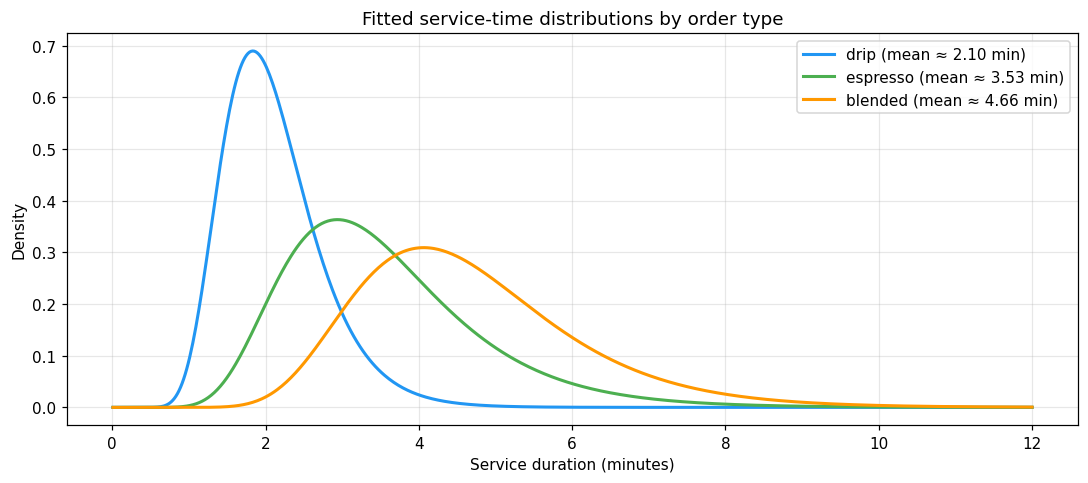

In [12]:
# Compare the three fitted PDFs on a single axis
fig, ax = plt.subplots(figsize=(10, 4.5))
xs = np.linspace(0.01, 12, 600)
for ot in order_types:
    pdf = stats.lognorm.pdf(xs, fits[ot]["sigma"], loc=0, scale=np.exp(fits[ot]["mu"]))
    ax.plot(xs, pdf, color=colors[ot], linewidth=2,
            label=f"{ot} (mean ≈ {fits[ot]['real_mean_min']:.2f} min)")

ax.set_xlabel("Service duration (minutes)")
ax.set_ylabel("Density")
ax.set_title("Fitted service-time distributions by order type")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Quick exploration — your turn

Modify the espresso `sigma` below and re-plot. Watch what happens to the right tail and to the 90th-percentile service time. The 90th percentile is the customer behind the complicated order; a longer right tail is what they feel.

> **Question to keep in mind:** if the shop trains every barista on espresso so that variability drops (`sigma` falls from 0.35 to, say, 0.20), how much does the P90 service time change? Is that worth the cost of training?

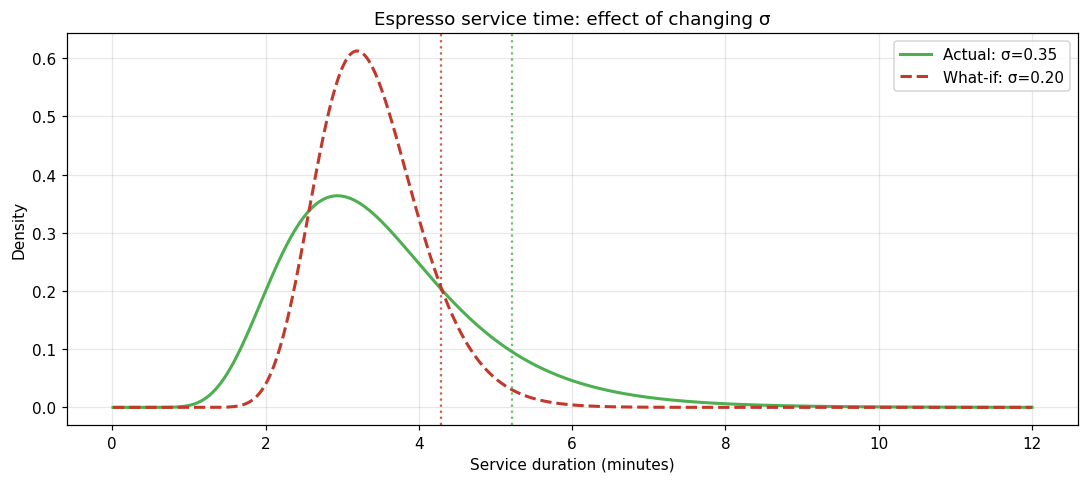

Actual  P90 service time: 5.21 min
What-if P90 service time: 4.29 min


In [13]:
# Try changing this and re-running the cell
espresso_sigma_what_if = 0.20

mu_real = fits["espresso"]["mu"]

xs = np.linspace(0.01, 12, 600)
pdf_actual = stats.lognorm.pdf(xs, fits["espresso"]["sigma"], loc=0, scale=np.exp(mu_real))
pdf_what_if = stats.lognorm.pdf(xs, espresso_sigma_what_if, loc=0, scale=np.exp(mu_real))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(xs, pdf_actual, color="#4CAF50", linewidth=2,
        label=f"Actual: σ={fits['espresso']['sigma']:.2f}")
ax.plot(xs, pdf_what_if, color="#C0392B", linewidth=2, linestyle="--",
        label=f"What-if: σ={espresso_sigma_what_if:.2f}")

# Mark the P90 of each
p90_actual = stats.lognorm.ppf(0.90, fits["espresso"]["sigma"], loc=0, scale=np.exp(mu_real))
p90_whatif = stats.lognorm.ppf(0.90, espresso_sigma_what_if, loc=0, scale=np.exp(mu_real))
ax.axvline(p90_actual, color="#4CAF50", linestyle=":", alpha=0.8)
ax.axvline(p90_whatif, color="#C0392B", linestyle=":", alpha=0.8)

ax.set_xlabel("Service duration (minutes)")
ax.set_ylabel("Density")
ax.set_title("Espresso service time: effect of changing σ")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Actual  P90 service time: {p90_actual:.2f} min")
print(f"What-if P90 service time: {p90_whatif:.2f} min")

## 6. Utilization sanity check

The fitted parameters give us everything we need to compute the analytical utilization for the morning rush. This is the M/M/c sanity check that anchors the simulation in Block 4 — if the simulation's utilization differs sharply from this calculation, something is wrong.

The math:

1. Weighted-mean service time across the order-type mix.
2. Service rate per barista is the inverse: 60 / mean service time, in customers per hour.
3. Utilization at the morning rush is arrival-rate / (number-of-baristas × service-rate-per-barista).

In [14]:
# Order-type mix (recovered from data)
mix = df['order_type'].value_counts(normalize=True)

# Weighted-mean service time using the fitted distribution means
weighted_mean_min = sum(mix[ot] * fits[ot]["real_mean_min"] for ot in order_types)
service_rate_per_barista = 60.0 / weighted_mean_min  # per hour

morning_arrival_rate = fitted_rate_per_hour  # from the exponential fit above

print(f"Weighted-mean service time:    {weighted_mean_min:.3f} min")
print(f"Service rate per barista:      {service_rate_per_barista:.2f} customers / hour")
print(f"Morning arrival rate:          {morning_arrival_rate:.2f} customers / hour")
print()
for c in (2, 3):
    rho = morning_arrival_rate / (c * service_rate_per_barista)
    print(f"Utilization with {c} baristas:        {rho:.3f}")

Weighted-mean service time:    3.342 min
Service rate per barista:      17.95 customers / hour
Morning arrival rate:          30.67 customers / hour

Utilization with 2 baristas:        0.854
Utilization with 3 baristas:        0.569


With two baristas the morning utilization is roughly 0.83. That is the number that will appear again in the simulation results in Block 4, and the gap between 83% and 56% (with three baristas) is the lever the owner is considering pulling.

A non-obvious takeaway worth pausing on: 83% utilization *sounds* comfortable. If the relationship between utilization and wait time were linear, going from 50% to 83% would only make waits 1.6× worse. In M/M/c, the actual blow-up is much steeper — wait times grow non-linearly as utilization approaches one. That is precisely why the owner sees long queues in spite of an 83% number on a spreadsheet, and it is the central lesson the discrete event simulation will visualize for them in the remaining blocks.

## What we leave Block 2 with

Three things head into the spec we will write in Block 3:

- A piecewise Poisson arrival process with five rate windows recovered from data, with the morning rush at roughly 30 customers per hour.
- Three lognormal service-time distributions, one per order type, parameterized by $(\mu, \sigma)$ with the values recovered above.
- An analytical utilization of about 0.83 in the morning rush at the current staffing level — the sanity-check number that the simulation must reproduce.

In Block 3 these distributions and parameters become rows in **Template A**, the process and resource specification, and from there in Block 4 they drive the SimPy code that the LLM generates.